# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [Sandy Aditya Anugrah Pratama]
- **Email:** [cdcc229d6y1382@student.devacademy.id]
- **ID Dicoding:** [CDCC229D6Y1382]

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh musim terhadap penyewaan sepeda?
- Berdasarkan waktu, kapan penyewaan sepeda paling tinggi?
- Apakah cuaca berpengaruh dalam penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Load tabel day yaitu data sewa sepeda dalam rentang hari

In [2]:
day_df = pd.read_csv ("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Load tabel hour yaitu data sewa sepeda dalam rentang jam

In [3]:
hour_df = pd.read_csv ("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Day dataset dan hour dataset memiliki struktur yang mirip, dengan perbedaan utama pada tingkat waktu.
- Pada info di kedua dataset, terdapat type data yang harus diubah yaitu pada dteday masih berupa object sehingga perlu diganti dengan datatime agar dapat digunakan dalam analisis berbasis waktu.
- Berdasarkan hasil pengecekan missing value pada kedua datset, tidak ditemukan missing values pada seluruh kolomnya yang berarti data telah lengkap dan tidak memerlukan proses imputasi atau penghapusan missing value.
- Tidak ditemukan data duplikat pada kedua dataset, sehingga seluruh baris data dianggap valid.
- Pada kolom season dan weathersit dalam bentuk numerik, sehingga perlu dilakukan transformasi ke bentuk kategori agar lebih mudah dipahami saat analisis.
- Kolom yr perlu diubah agar data terlihat jelas antara tahun 2011 dan 2012

### Cleaning Data

In [11]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [12]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [13]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [14]:
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

weather_map = {
    1: 'Clear',
    2: 'Cloudy',
    3: 'Rain',
}

year_map ={
    0: '2011',
    1: '2012'
}
day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)
day_df['yr'] = day_df['yr'].map(year_map)

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)
hour_df['yr'] = hour_df['yr'].map(year_map)


In [15]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,2011,1,0,6,0,Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Winter,2011,1,0,0,0,Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Winter,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Winter,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Winter,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [16]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,2011,1,0,0,6,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Winter,2011,1,1,0,6,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Winter,2011,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Winter,2011,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Winter,2011,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Pada kedua dataset, kolom dteday dikonversi dari tipe data object menjadi datetime agar data dapat dianalisis berdasarkan waktu, seperti tren harian, bulanan, maupun tahunan.
- Kolom yr, season, dan weathersit diubah dari bentuk numerik menjadi label kategorikal. Transformasi ini bertujuan untuk meningkatkan keterbacaan data dan mempermudah interpretasi pada visualisasi.

## Exploratory Data Analysis (EDA)

### Explore ...

In [17]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Summer,2012,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,366,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [18]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17376,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Summer,2012,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [19]:
season_rent = day_df.groupby('season')['cnt'].mean().sort_values(ascending=False)
season_rent

,cnt
season,
Summer,5644.303191
Spring,4992.331522
Fall,4728.162921
Winter,2604.132597


In [20]:
hour_rent = hour_df.groupby('hr')['cnt'].mean()
hour_rent

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [21]:
weather_rent = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)
weather_rent

,cnt
weathersit,
Clear,4876.786177
Cloudy,4035.862348
Rain,1803.285714


In [22]:
yearly_rent = day_df.groupby('yr')['cnt'].sum()
print(yearly_rent)

yr
2011    1243103
2012    2049576
Name: cnt, dtype: int64


**Insight:**
- Statistik Deskriptif:
    - Rata-rata penyewaan harian adalah sekitar 4504, dengan standar deviasi yang cukup tinggi yaitu 1937, menunjukkan variabilitas harian yang signifikan.
    - Rata-rata penyewaan per jam adalah sekitar 189, dengan standar deviasi yang juga tinggi yaitu 181, menandakan fluktuasi besar dalam penyewaan per jam.
    - Kolom kategori seperti 'season' dan 'weathersit' memiliki jumlah nilai unik yang sesuai dan distribusi yang wajar, dengan 'Fall' dan 'Clear' sebagai kategori yang paling sering muncul.
- Dapat dilihat pada rata-rata penyewaan berdasarkan musim bahwa musim panas (summer) memiliki rata-rata penyewaan tertinggi sekitar 5644, sementara musim dingin (winter) memiliki rata-rata terendah sekitar 2604. Ini menunjukkan preferensi pengguna terhadap kondisi musiman tertentu.
- Dapat dilihat pada rata-rata penyewaan per jam, pola penyewaan per jam menunjukkan puncaknya pada jam sibuk pagi sekitar pukul 08:00 dan sore sekitar pukul 17:00-18:00, dengan rata-rata penyewaan terendah pada dini hari.
- Dapat dilihat pada rata-rata penyewaan berdasarkan cuaca, kondisi cuaca cerah (clear) mengindikasikan rata-rata penyewaan tertinggi sekitar 4876, sedangkan cuaca hujan (rain) memiliki rata-rata penyewaan terendah yaitu sekitar 1803. Ini menunjukkan sensitivitas penyewaan terhadap kondisi cuaca.
- Dapat dilihat bahwa total penyewaan tahun 2011 sebesar 12343103  dan 2012 naik menjadi 2049576, ini menunjukan kenaikan yang signifikan antara tahun 2011 dan 2012

## Visualization & Explanatory Analysis

### Pertanyaan 1:

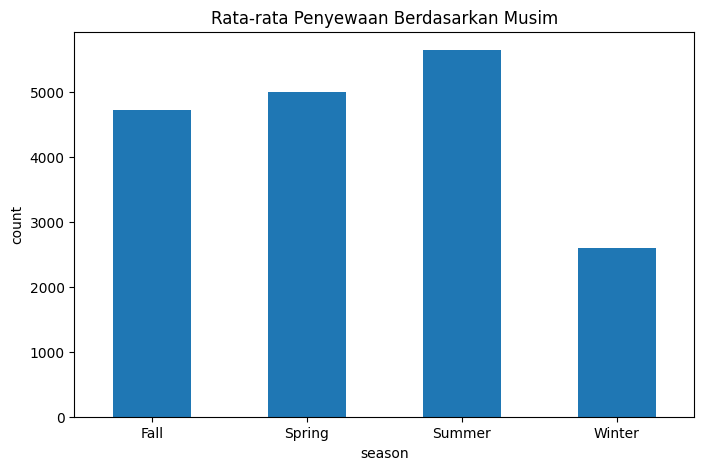

In [29]:
season_rent = day_df.groupby('season')['cnt'].mean()

plt.figure(figsize=(8,5))
season_rent.plot(kind='bar')
plt.title('Rata-rata Penyewaan Berdasarkan Musim')
plt.xlabel('season')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

### Pertanyaan 2:

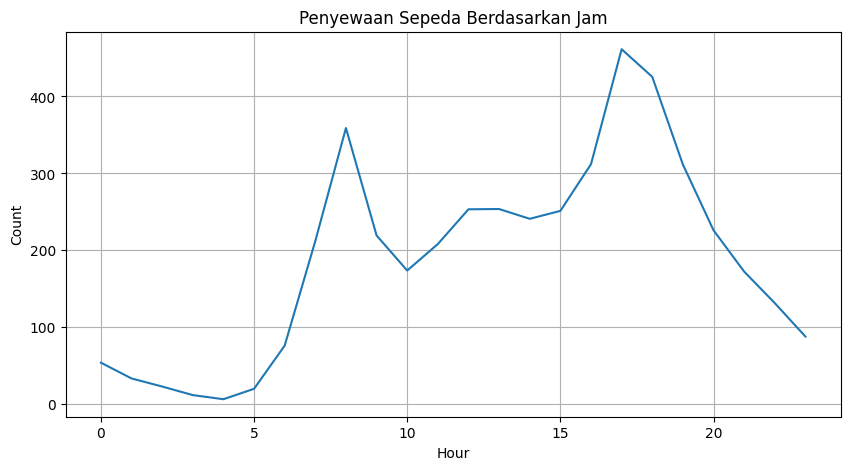

In [24]:
hour_rent = hour_df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10,5))
plt.plot(hour_rent)
plt.title('Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.grid()
plt.show()

##Pertanyaan 3 :

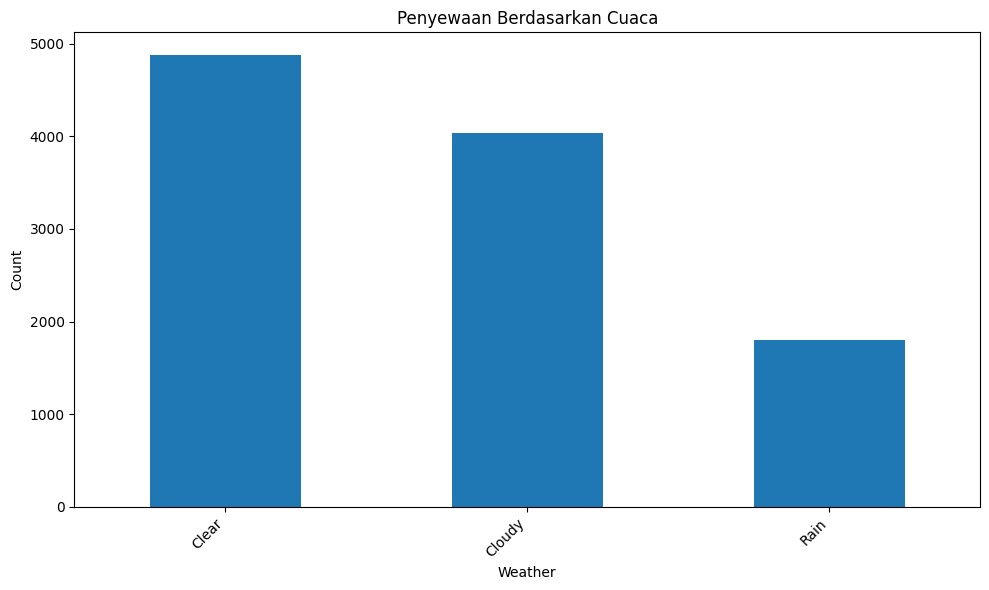

In [25]:
weather_rent = day_df.groupby('weathersit')['cnt'].mean()
plt.figure(figsize=(10, 6))
weather_rent.plot(kind='bar')
plt.title('Penyewaan Berdasarkan Cuaca')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Penyewaan per tahun

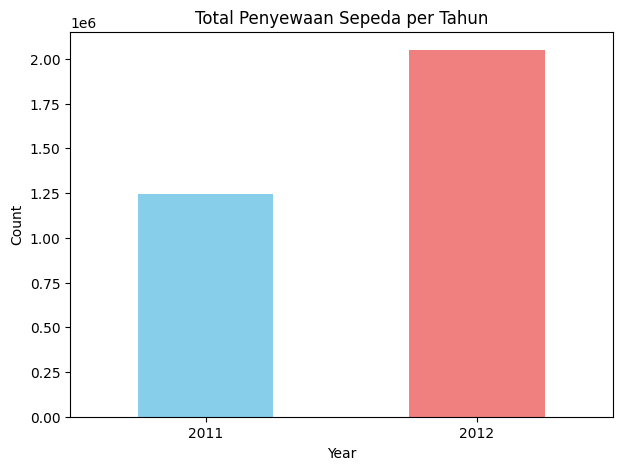

In [26]:
plt.figure(figsize=(7,5))
yearly_rent.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Total Penyewaan Sepeda per Tahun')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Insight:**
- ([Pertanyaan 1] Bagaimana pengaruh musim terhadap penyewaan sepeda?): Dari grafik rata-rata penyewaan berdasarkan musim, terlihat bahwa musim panas (summer) memiliki rata-rata penyewaan sepeda tertinggi, diikuti oleh musim semi (spring) dan musim gugur (fall). Sedangkan dingin (winter) menunjukkan rata-rata penyewaan terendah. Hal ini menunjukkan adanya pengaruh signifikan musim terhadap minat masyarakat dalam menyewa sepeda.
- ([Pertanyaan 2] Berdasarkan waktu, kapan penyewaan sepeda paling tinggi?): Grafik penyewaan sepeda berdasarkan jam menunjukkan bahwa jumlah penyewaan paling tinggi terjadi pada jam-jam sibuk, yaitu sekitar pukul 08:00 (pagi) dan 17:00-18:00 (sore/pulang kerja). Ini mengindikasikan bahwa sepeda banyak digunakan sebagai transportasi untuk berangkat dan pulang kerja atau sekolah. Rata-rata penyewaan terendah terjadi pada dini hari (pukul 02:00-04:00).
- ([Pertanyaan 3] Apakah cuaca berpengaruh dalam penyewaan sepeda?): Dari grafik penyewaan berdasarkan kondisi cuaca, kondisi cuaca cerah (clear) memiliki rata-rata penyewaan sepeda tertinggi, diikuti oleh berawan (cloudy). Sedangkan kondisi hujan (rain) menunjukkan rata-rata penyewaan yang jauh lebih rendah. Hal ini jelas menunjukkan bahwa kondisi cuaca yang baik sangat mendukung aktivitas bersepeda, sementara cuaca buruk dapat mengurangi jumlah penyewaan secara drastis.
- Penyewaan Per Tahun : Dari grafik penyewaan pertahun dapat dilihat bahwa adanya peningkatan jumlah penyewa pada tahun 2011 ke 2012. Ini menandakan adanya peningkatan yang signifikan antara tahun 2011 dengan tahun 2012 dimana awalnya hanya 12343103 penyewa menjadi 2049576.

## Analisis Lanjutan (Opsional)

In [27]:
def activity_cluster(hr):
    if 7 <= hr <= 9:
        return 'Morning Activity'
    elif 17 <= hr <= 19:
        return 'Evening Activity'
    elif 10 <= hr <= 16:
        return 'Daytime Activity'
    else:
        return 'Low Activity'

hour_df['activity_cluster'] = hour_df['hr'].apply(activity_cluster)

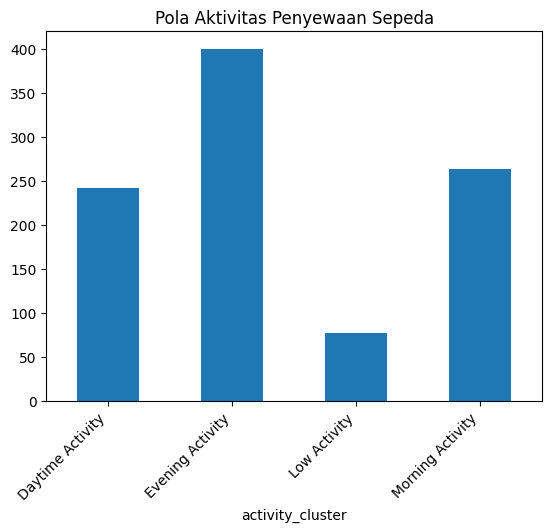

In [28]:
hour_df.groupby('activity_cluster')['cnt'].mean().plot(kind='bar')
plt.title('Pola Aktivitas Penyewaan Sepeda')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight (Analisis Lanjutan - Clustering Aktivitas):**
- Dengan mengelompokkan jam-jam dalam sehari menjadi kategori aktivitas ('Morning Activity', 'Evening Activity', 'Daytime Activity', 'Low Activity'), terlihat jelas bahwa 'Evening Activity' dan 'Morning Activity' memiliki rata-rata penyewaan sepeda tertinggi.
- Hal ini menegaskan bahwa penggunaan sepeda sangat dominan selama jam-jam sibuk pulang-pergi kerja.
- Kategori 'Daytime Activity' juga menunjukkan rata-rata penyewaan yang cukup tinggi, menandakan penggunaan sepeda untuk aktivitas rekreasi di siang hari.
- 'Low Activity' memiliki rata-rata penyewaan terendah, yang sesuai karena meliputi jam-jam dini hari di mana aktivitas umum cenderung minim.

## Conclusion

## Conclusion

- Conclution pertanyaan 1: Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?
  Musim sangat berpengaruh terhadap jumlah penyewaan sepeda. Musim panas (summer) memiliki rata-rata penyewaan tertinggi, diikuti oleh musim semi (spring) dan musim gugur (fall). Sedangkan musim dingin (winter) menunjukkan rata-rata penyewaan terendah. Ini mengindikasikan preferensi pengguna terhadap kondisi musiman tertentu untuk bersepeda, di mana cuaca hangat dan hari yang lebih panjang di musim panas mendukung aktivitas luar ruangan seperti bersepeda, sementara cuaca dingin di musim dingin cenderung mengurangi minat bersepeda.

- Conclution pertanyaan 2: Pada jam berapa penyewaan sepeda paling tinggi?
  Penyewaan sepeda paling tinggi terjadi pada jam-jam sibuk pagi (sekitar pukul 08:00) dan sore hari (sekitar pukul 17:00-18:00). Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas sehari-hari, seperti berangkat dan pulang dari tempat kerja atau sekolah.

- Conclution pertanyaan 3: Apakah cuaca berpengaruh dalam penyewaan sepeda?
  Cuaca memiliki pengaruh signifikan terhadap penyewaan sepeda. Kondisi cuaca cerah (clear) memiliki rata-rata penyewaan sepeda tertinggi, menunjukkan bahwa orang lebih cenderung menyewa sepeda saat cuaca baik dan mendukung aktivitas di luar ruangan. Sebaliknya, kondisi cuaca buruk seperti hujan (rain) menyebabkan penurunan drastis pada jumlah penyewaan, karena cuaca yang tidak menguntungkan menghambat minat dan kenyamanan bersepeda.